In [ ]:
import uuid
from IPython.display import clear_output

thread_id = f"rca-{uuid.uuid4().hex[:8]}"
print(f"✓ Interactive RCA Agent (Thread: {thread_id})\n")

user_input = input("You: ").strip()

if user_input:
    state = AgentState(messages=[HumanMessage(content=user_input)])
    result = graph.invoke(
        state,
        config={"configurable": {"thread_id": thread_id}}
    )
    
    # Display the agent's response
    for msg in result["messages"]:
        if isinstance(msg, AIMessage) and msg.content:
            print(f"\nAgent:\n{msg.content}\n")
            break
    
    # Show extracted hypotheses if any
    if result["hypotheses"]:
        print("## Evidence")
        for h in sorted(result["hypotheses"], key=lambda x: x.confidence, reverse=True):
            status_emoji = {"CONFIRMED": "✓", "REJECTED": "✗", "RECURRENT": "★", "LIKELY": "◎", "ACTIVE": "○"}.get(h.status, "·")
            print(f"{status_emoji} {h.source_id} [{h.status}] {h.statement} (conf={h.confidence:.2f})")


✓ Interactive RCA Agent (Thread: rca-55d79811)



## Imports

In [ ]:
import sys
import os

# Add notebooks dir to path so tools and utils are importable
notebook_dir = os.path.dirname(os.path.abspath("20-rca-react-agent.ipynb"))
sys.path.insert(0, notebook_dir)

from typing import Any, Annotated, List, Literal
from operator import add
import uuid

import re

from openai import OpenAI
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

from tools.tools import (

    get_current_date, calculate_date_window,
    check_machine_exists, list_available_machines,
    get_formatted_procedure_context,
    get_recent_formatted_cm_context,
    get_long_formatted_cm_context,
    get_formatted_cm_context,
    get_sensor_catalog_tool, get_threshold_events_tool,
    get_sensor_timeline_tool, get_sensor_readings_tool,
    get_sensor_anomaly_summary,
    get_remaining_life_tool,
    query_known_issues_graph,
    get_intervention_detail,
    get_fleet_impact_for_symptom,
)

from utils.prompt_management import prompt_template_config


GENERATION_MODEL = "gpt-4o-mini"

## States

In [ ]:
class Reference(BaseModel):
    source_id: str
    source_type: Literal['PROC_REF', 'GRAPH', 'INT', 'USER']

class Hypothesis(BaseModel):
    source_id: str
    statement: str
    confidence: float
    status: Literal['PRIOR', 'ACTIVE', 'CONFIRMED', 'REJECTED', 'LIKELY']
    source: list[Reference] = []
    last_delta: float = 0.0       # +0.30, -0.25, etc.
    last_reason: str = ""         # "KG match", "technician confirmed", "contradicted by user"
    explanation: str = ""         # 1-sentence physical/functional explanation for operator

class ContextInfo(BaseModel):
    machine_id: str = Field(description="Machine ID like CB-200, HX-150")
    symptom: str = Field(description="What's wrong: high temperature, vibration, noise, etc.")
    time_period: str = Field(description="When it started: today, past hour, last week, '2025-04-01' etc.")


class AgentState(BaseModel):
    messages: Annotated[List[Any], add] = Field(default_factory=list)
    hypotheses: list[Hypothesis] = Field(default_factory=list)
    machine: str = ""
    symptom: str = ""
    period: str = ""
    awaiting_user: bool = False
    completed_context: bool = False
    procedure_checkpoint_asked: bool = False  # Track if we've asked about high-conf procedures

# Confidence thresholds (per system prompt spec)
CONFIRMED = 0.80      # conf ≥ 0.80
LIKELY = 0.75          # precision match
ACTIVE = 0.25         # confirmed intervention
REJECTED = 0.20       # conf ≤ 0.20
PRIOR = 0.0           # default/no evidence

## Tools

In [ ]:
ALL_TOOLS = [
    get_current_date, calculate_date_window,
    check_machine_exists, list_available_machines,
    get_formatted_procedure_context,
    get_recent_formatted_cm_context,
    get_long_formatted_cm_context,
    get_formatted_cm_context,
    get_sensor_catalog_tool, get_threshold_events_tool,
    get_sensor_timeline_tool, get_sensor_readings_tool,
    get_sensor_anomaly_summary,
    get_remaining_life_tool,
    query_known_issues_graph,
    get_intervention_detail,
    get_fleet_impact_for_symptom,
]

print(f"Defined {len(ALL_TOOLS)} tools: {[t.name for t in ALL_TOOLS]}")


_llm = ChatOpenAI(model=GENERATION_MODEL)
_llm_with_tools = _llm.bind_tools(ALL_TOOLS, tool_choice="auto")

## Agent Node

In [ ]:
def infer_source_type(source_id: str) -> Literal['PROC_REF', 'GRAPH', 'INT', 'USER']:
    """Infer source type from source ID pattern."""
    if source_id.upper() == 'USER':
        return 'USER'
    
    prefix = source_id.split('-')[0].upper() if '-' in source_id else source_id.upper()

    if prefix in ('INT', 'INTV'):
        return 'INT'
    elif prefix in ('KG', 'GRAPH', 'KNOWN'):
        return 'GRAPH'
    elif prefix in ('PROC', 'PROC_REF', 'PROC_ID'):
        return 'PROC_REF'
    else:
        return 'PROC_REF'

def extract_hypotheses(response_text: str) -> list[Hypothesis]:
    """
    Parse ledger display from response and extract hypotheses.
    Status key: ✓ CONFIRMED · ✗ REJECTED · ◎ LIKELY · ○ ACTIVE · · PRIOR
    """
    hypotheses = []

    ledger_match = re.search(r'---\n(.*?)\n---', response_text, re.DOTALL)
    if not ledger_match:
        return hypotheses

    ledger_text = ledger_match.group(1)
    entries = re.split(r'\n(?=[✓✗◎○·])', ledger_text.strip())

    # Map emoji to status
    emoji_to_status = {
        '✓': 'CONFIRMED',
        '✗': 'REJECTED',
        '◎': 'LIKELY',
        '○': 'ACTIVE',
        '·': 'PRIOR'
    }

    for entry in entries:
        if not entry.strip():
            continue

        # Parse: ✓ H1 [status] Statement — conf=0.92 (+0.30 KG match)
        match = re.match(
            r'([✓✗◎○·])\s+([H\d]+)\s+\[(\w+)\]\s+(.+?)\s+—\s+conf=([\d.]+)(?:\s+\(([+-]?[\d.]+)\s+(.+?)\))?',
            entry
        )

        if match:
            emoji, h_id, status_text, statement, conf, delta_str, reason = match.groups()
            
            # Use emoji-mapped status if bracket status doesn't match
            status = emoji_to_status.get(emoji, status_text)

            # Extract explanation if present
            explanation_match = re.search(r'Explanation:\s+(.+?)(?:\n|$)', entry)
            explanation = explanation_match.group(1).strip() if explanation_match else ""

            sources_match = re.search(r'Sources:\s+(.+?)(?:\n|$)', entry)
            sources = sources_match.group(1).split(', ') if sources_match else []

            references = [
                Reference(source_id=s.strip(), source_type=infer_source_type(s.strip()))
                for s in sources
            ]

            last_delta = float(delta_str) if delta_str else 0.0
            last_reason = reason if reason else ""

            hypotheses.append(Hypothesis(
                source_id=h_id,
                statement=statement.strip(),
                confidence=float(conf),
                status=status,
                source=references,
                last_delta=last_delta,
                last_reason=last_reason,
                explanation=explanation
            ))

    return hypotheses


def extract_context_info(messages) -> dict:
    """
    Function to extract the context
    """
    CONTEXT_EXTRACTION_PROMPT = """

    **Machine Identification:**
    - Extract the machine ID (e.g., CB-200, HX-150, PM-75)
    - Machine IDs follow pattern: 2-3 uppercase letters + hyphen + number
    - If unclear, ask user to clarify: "Which machine are we investigating?"

    **Symptom Description:**
    - What is wrong with the machine? Be specific
    - Examples: "high oil temperature affecting the gate", "unusual vibration near bearing", "pressure drop in main line"
    - If vague (e.g., "not working"), ask: "Can you describe the specific symptom? (e.g., temperature, noise, vibration, pressure, speed, leaks)"

    **Time Period:**
    - When did this start or how long has it been happening?
    - Examples: "today", "past hour", "last week", "since Monday", "2025-01-01"
    - If unclear, ask: "How long has this been going on?"

    **Output Format:**
    Return as JSON with three fields:
    ```json
    {
    "machine_id": "CB-200",
    "symptom": "high oil temperature warnings",
    "time_period": "past hour"
    }

    """

    _llm_context_info = _llm.with_structured_output(ContextInfo)

    response = _llm_context_info.invoke(
        [SystemMessage(content=CONTEXT_EXTRACTION_PROMPT),
        messages[-1]]
    )

    return response

In [ ]:
def format_ledger_for_context(hypotheses: list[Hypothesis]) -> str:
    """
    Format current hypotheses as a readable ledger for LLM context.
    Shows: status, ID, statement, confidence, sources, last delta and reason, explanation.
    """
    if not hypotheses:
        return "(No hypotheses yet — starting fresh)"

    lines = []
    for h in sorted(hypotheses, key=lambda x: x.confidence, reverse=True):
        status_emoji = {
            "CONFIRMED": "✓",
            "REJECTED": "✗",
            "LIKELY": "◎",
            "ACTIVE": "○",
            "PRIOR": "·"
        }.get(h.status, "·")

        sources_str = ", ".join([s.source_id for s in h.source]) if h.source else "no sources yet"
        
        delta_str = ""
        if h.last_reason:
            sign = "+" if h.last_delta >= 0 else ""
            delta_str = f" ({sign}{h.last_delta:.2f} {h.last_reason})"
        
        entry = f"{status_emoji} {h.source_id} [{h.status}] {h.statement} — conf={h.confidence:.2f}{delta_str}"
        
        if h.explanation:
            entry += f"\n  Explanation: {h.explanation}"
        
        entry += f"\n  Sources: {sources_str}"
        lines.append(entry)

    return "\n".join(lines)

In [ ]:
def deduplicate_sources(hypotheses: list[Hypothesis]) -> list[Hypothesis]:
    """
    Ensure each source_id appears only once across all hypotheses.
    When a source appears in multiple hypotheses, assign it to the one with highest confidence.
    Also deduplicate within each hypothesis's source list.
    """
    # First, deduplicate within each hypothesis's source list
    for h in hypotheses:
        seen = set()
        deduplicated = []
        for ref in h.source:
            if ref.source_id not in seen:
                deduplicated.append(ref)
                seen.add(ref.source_id)
        h.source = deduplicated

    # Now deduplicate across hypotheses: build a map of all source_ids to hypotheses they appear in
    source_to_hypotheses = {}
    for h in hypotheses:
        for ref in h.source:
            if ref.source_id not in source_to_hypotheses:
                source_to_hypotheses[ref.source_id] = []
            source_to_hypotheses[ref.source_id].append(h.source_id)

    # For sources that appear in multiple hypotheses, keep only in the one with highest confidence
    for source_id, h_ids in source_to_hypotheses.items():
        if len(h_ids) > 1:
            # Find hypothesis with highest confidence among the duplicates
            duplicates = [h for h in hypotheses if h.source_id in h_ids]
            max_conf_hyp = max(duplicates, key=lambda x: x.confidence)

            # Remove source from all but the max confidence one
            for h in hypotheses:
                if h.source_id != max_conf_hyp.source_id:
                    h.source = [ref for ref in h.source if ref.source_id != source_id]

    return hypotheses


def merge_hypotheses(old_hypotheses: list[Hypothesis], new_hypotheses: list[Hypothesis]) -> list[Hypothesis]:
    """
    Merge old and new hypotheses by source_id, with global source deduplication.

    Strategy:
    - If new hypothesis has same source_id as old, replace it (LLM refined/updated it)
    - If source_id is new, append it
    - Preserve old hypotheses not mentioned in new list
    - Deduplicate sources: each source_id appears only once across all hypotheses

    Example:
      Old: [H1(conf=0.50, sources=[S1]), H2(conf=0.60, sources=[S2])]
      New: [H1(conf=0.75, sources=[S1, S3]), H3(conf=0.40, sources=[S2])]
      Result: [H1(conf=0.75, sources=[S1, S3]), H2(conf=0.60, sources=[]), H3(conf=0.40, sources=[S2])]
      (S2 moved from H2 to H3 because H3 has higher priority)
    """
    if not new_hypotheses:
        merged = old_hypotheses
    else:
        # Build a map of old hypotheses by ID
        old_by_id = {h.source_id: h for h in old_hypotheses}

        # Build a map of new hypotheses by ID
        new_by_id = {h.source_id: h for h in new_hypotheses}

        # Start with old hypotheses
        merged = list(old_hypotheses)

        # For each new hypothesis
        for h_id, new_h in new_by_id.items():
            if h_id in old_by_id:
                # Replace the old one with the new one
                merged = [new_h if h.source_id == h_id else h for h in merged]
            else:
                # New ID, append it
                merged.append(new_h)

    # Apply global source deduplication
    merged = deduplicate_sources(merged)

    return merged

In [ ]:
def update_status_transitions(hypothesis: Hypothesis) -> Hypothesis:
    """
    Enforce status transitions based on confidence thresholds.
    Per spec: PRIOR (default) · ACTIVE (≥0.25) · LIKELY (precision, ≥0.75) · CONFIRMED (≥0.80) · REJECTED (≤0.20)
    """
    if hypothesis.confidence >= CONFIRMED:
        hypothesis.status = 'CONFIRMED'
    elif hypothesis.confidence >= LIKELY:
        hypothesis.status = 'LIKELY'
    elif hypothesis.confidence >= ACTIVE:
        hypothesis.status = 'ACTIVE'
    elif hypothesis.confidence <= REJECTED:
        hypothesis.status = 'REJECTED'
    else:
        hypothesis.status = 'PRIOR'

    return hypothesis


def find_procedure_checkpoint_candidate(hypotheses: list[Hypothesis]) -> tuple[bool, str, Hypothesis | None]:
    """
    Check if there's a high-confidence hypothesis with PROC_REF sources that we should ask about.
    Returns: (should_checkpoint, procedure_name, hypothesis)
    """
    for h in sorted(hypotheses, key=lambda x: x.confidence, reverse=True):
        # Only checkpoint if confidence >= 0.75 and has procedure sources
        if h.confidence >= LIKELY and h.source:
            proc_sources = [s for s in h.source if s.source_type == 'PROC_REF']
            if proc_sources:
                return (True, proc_sources[0].source_id, h)
    return (False, "", None)

In [ ]:
def agent_node(state):
    """Agent node: invoke LLM with tools and process response."""
    
    # Handle both dict and AgentState
    if isinstance(state, dict):
        state = AgentState(**state)
    
    # STAGE 1: Intake — extract and validate machine, symptom, period
    if not state.completed_context:
        # Get latest user message
        user_messages = [m for m in state.messages if isinstance(m, HumanMessage)]
        if user_messages:
            
            context = extract_context_info(user_messages)
            
            state.machine = context.machine_id if context.machine_id else ""
            state.symptom = context.symptom if context.symptom else ""
            state.period = context.time_period if context.time_period else ""
        
        # Check what's missing
        missing = []
        if not state.machine:
            missing.append("machine ID")
        if not state.symptom:
            missing.append("symptom description")
        if not state.period:
            missing.append("time reference")
        
        # If anything missing, ask for it (don't call tools yet)
        if missing:
            ask_msg = f"I need a bit more information to get started. Could you clarify: {', '.join(missing)}?"
            return {
                "messages": [AIMessage(content=ask_msg)],
                "machine": state.machine,
                "symptom": state.symptom,
                "period": state.period,
                "hypotheses": [],
                "awaiting_user": True,
                "completed_context": False,
                "procedure_checkpoint_asked": False,
            }
        
        # Intake complete, mark it
        state.completed_context = True
    
    # STAGE 2+: Call LLM for reasoning and tool use
    SYSTEM_PROMPT = prompt_template_config("prompts/rca_react_system_prompt.yml", name="system_prompt")
    messages = state.messages

    # Include current ledger so LLM knows what hypotheses it's working with
    ledger_context = format_ledger_for_context(state.hypotheses)
    augmented_prompt = f"{SYSTEM_PROMPT}\n\n## Current Evidence Ledger\n\n{ledger_context}"

    response = _llm_with_tools.invoke(
        [SystemMessage(content=augmented_prompt), *messages[:15]]
    )

    response_text = response.content if hasattr(response, 'content') else str(response)

    # If LLM decided to call tools, return response with tool calls
    if response.tool_calls:
        return {
            "messages": [response],
            "machine": state.machine,
            "symptom": state.symptom,
            "period": state.period,
            "hypotheses": state.hypotheses,
            "awaiting_user": False,
            "completed_context": state.completed_context,
            "procedure_checkpoint_asked": state.procedure_checkpoint_asked,
        }

    # Text-only response (no tool calls) — extract hypotheses and awaiting state
    new_hypotheses = extract_hypotheses(response_text)
    new_hypotheses = [update_status_transitions(h) for h in new_hypotheses]
    
    # Merge by source_id: replace old if ID matches, append if new
    merged_hypotheses = merge_hypotheses(state.hypotheses, new_hypotheses)
    
    # Check for procedure checkpoint: if not yet asked AND we have high-conf procedure hypothesis
    should_checkpoint, proc_id, proc_hyp = find_procedure_checkpoint_candidate(merged_hypotheses)
    
    if should_checkpoint and not state.procedure_checkpoint_asked:
        # Ask about the procedure instead of proceeding further
        checkpoint_msg = (
            f"I found a procedure that covers this issue: **{proc_id}**. "
            f"It matches your situation with {proc_hyp.confidence:.0%} confidence.\n\n"
            f"**Have you already followed this procedure?** If so, what was the outcome? "
            f"If not, I can help guide you through the key diagnostic steps."
        )
        return {
            "messages": [AIMessage(content=checkpoint_msg)],
            "machine": state.machine,
            "symptom": state.symptom,
            "period": state.period,
            "hypotheses": merged_hypotheses,
            "awaiting_user": True,
            "completed_context": state.completed_context,
            "procedure_checkpoint_asked": True,  # Mark that we asked
        }
    
    # No procedure checkpoint needed, proceed with normal response
    is_awaiting = "[AWAITING USER FEEDBACK]" in response_text
    cleaned_response = response_text.replace("[AWAITING USER FEEDBACK]", "").strip()

    return {
        "messages": [AIMessage(content=cleaned_response)],
        "machine": state.machine,
        "symptom": state.symptom,
        "period": state.period,
        "hypotheses": merged_hypotheses,
        "awaiting_user": is_awaiting,
        "completed_context": state.completed_context,
        "procedure_checkpoint_asked": state.procedure_checkpoint_asked or should_checkpoint,
    }

In [9]:
state = AgentState(messages=[HumanMessage(content="Hi there")])
result = agent_node(state)
print("Content type:", type(result["messages"][0].content))
print("Content length:", len(result["messages"][0].content) if result["messages"][0].content else 0)
print(result["messages"][0].content[:100] if result["messages"][0].content else "(empty)")

Content type: <class 'str'>
Content length: 113
I need a bit more information to get started. Could you clarify: machine ID, symptom description, ti


In [10]:
def route_after_agent(state: AgentState) -> str:
    last_msg = state.messages[-1]

    if isinstance(last_msg, AIMessage) and last_msg.tool_calls:
        return "tools"

    elif state.awaiting_user:
        return "user_feedback"

    return "__end__"


def user_feedback_node(state: AgentState) -> dict:
    return {}

def route_after_tools(state: AgentState) -> str:
    """Route after tools: always back to agent for reasoning."""
    return "agent"


In [11]:
tool_node = ToolNode(ALL_TOOLS)

workflow = StateGraph(AgentState)

# Add all nodes
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)
workflow.add_node("user_feedback", user_feedback_node)

# Define edges
workflow.add_edge(START, "agent")  # Always start with agent
workflow.add_conditional_edges("agent", route_after_agent, {
    "tools": "tools",
    "user_feedback": "user_feedback",
    "__end__": END
})
workflow.add_conditional_edges("tools", route_after_tools, {
    "agent": "agent"
})
workflow.add_edge("user_feedback", END)  # Pause here, wait for next user input

# Compile with memory
graph = workflow.compile(checkpointer=MemorySaver())


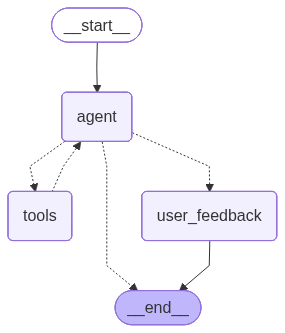

In [12]:

from utils.utils import display_graph
display_graph(graph)

In [13]:
state = AgentState(messages=[
    HumanMessage(content="The HX-200 hydraulic press is showing high oil temperature warnings. Check the current sensor readings, the remaining life of its components, and look up the troubleshooting procedure for overtemperature faults.")
])
result = graph.invoke(
    state,
    config={"configurable": {"thread_id": "hx200-case2"}}
)

# Show last message (should be non-empty now if tools were called and agent responded)
for msg in result["messages"]:
    if isinstance(msg, AIMessage):
        print(f"AI: {msg.content[:200] if msg.content else '(empty)'}")
        if msg.tool_calls:
            tool_names = [tc.get('name') if isinstance(tc, dict) else tc.name for tc in msg.tool_calls]
            print(f"  Tool calls: {tool_names}")
    elif isinstance(msg, HumanMessage):
        print(f"Human: {msg.content[:100]}")


Human: The HX-200 hydraulic press is showing high oil temperature warnings. Check the current sensor readin
AI: I need a bit more information to get started. Could you clarify: time reference?


In [ ]:
import uuid
from IPython.display import clear_output

thread_id = f"rca-{uuid.uuid4().hex[:8]}"
print(f"✓ Interactive RCA Agent (Thread: {thread_id})\n")

user_input = input("You: ").strip()

if user_input:
    state = AgentState(messages=[HumanMessage(content=user_input)])
    result = graph.invoke(
        state,
        config={"configurable": {"thread_id": thread_id}}
    )
    
    # Display the agent's response
    for msg in result["messages"]:
        if isinstance(msg, AIMessage) and msg.content:
            print(f"\nAgent:\n{msg.content}\n")
            break
    
    # Show extracted hypotheses if any
    if result["hypotheses"]:
        print("## Evidence")
        for h in sorted(result["hypotheses"], key=lambda x: x.confidence, reverse=True):
            status_emoji = {"CONFIRMED": "✓", "REJECTED": "✗", "RECURRENT": "★", "LIKELY": "◎", "ACTIVE": "○"}.get(h.status, "·")
            print(f"{status_emoji} {h.source_id} [{h.status}] {h.statement} (conf={h.confidence:.2f})")

✓ Interactive RCA Agent (Thread: rca-85fc058c)



In [15]:
## Test: Hypothesis Accumulation - SIMPLE CASE (No tool calls)

print("=" * 70)
print("TEST: Hypothesis Merging Logic")
print("=" * 70)
print("\nDemonstrating hypothesis merging by ID without tool invocation.\n")

# Directly test the merge_hypotheses function
h1_v1 = Hypothesis(source_id="H1", statement="Low oil level", confidence=0.50, status="ACTIVE", source=[])
h2_v1 = Hypothesis(source_id="H2", statement="Bearing wear", confidence=0.60, status="ACTIVE", source=[])

h1_v2 = Hypothesis(source_id="H1", statement="Low oil level", confidence=0.75, status="CONFIRMED", source=[])  # Updated
h3_v1 = Hypothesis(source_id="H3", statement="Fan failure", confidence=0.40, status="PRIOR", source=[])  # New

print("Initial state (Turn 1):")
old_list = [h1_v1, h2_v1]
for h in old_list:
    print(f"  {h.source_id}: {h.statement} (conf={h.confidence:.2f})")

print("\nAgent extracts new hypotheses (Turn 2):")
new_list = [h1_v2, h3_v1]
for h in new_list:
    print(f"  {h.source_id}: {h.statement} (conf={h.confidence:.2f})")

print("\nMerging (H1 updated, H2 preserved, H3 added):")
merged = merge_hypotheses(old_list, new_list)
for h in merged:
    print(f"  {h.source_id}: {h.statement} (conf={h.confidence:.2f}, status={h.status})")

print(f"\n✅ Merge worked correctly! Old hypotheses preserved, new ones added/updated.")
print(f"   Total hypotheses: {len(merged)}")

# Verify the merge
assert len(merged) == 3, "Should have 3 hypotheses"
assert merged[0].source_id == "H1" and merged[0].confidence == 0.75, "H1 should be updated to 0.75"
assert merged[1].source_id == "H2" and merged[1].confidence == 0.60, "H2 should still be 0.60"
assert merged[2].source_id == "H3", "H3 should be added"

print(f"\n{'=' * 70}")
print(f"Test complete. Hypothesis merging logic is working correctly!")
print(f"{'=' * 70}")

TEST: Hypothesis Merging Logic

Demonstrating hypothesis merging by ID without tool invocation.

Initial state (Turn 1):
  H1: Low oil level (conf=0.50)
  H2: Bearing wear (conf=0.60)

Agent extracts new hypotheses (Turn 2):
  H1: Low oil level (conf=0.75)
  H3: Fan failure (conf=0.40)

Merging (H1 updated, H2 preserved, H3 added):
  H1: Low oil level (conf=0.75, status=CONFIRMED)
  H2: Bearing wear (conf=0.60, status=ACTIVE)
  H3: Fan failure (conf=0.40, status=PRIOR)

✅ Merge worked correctly! Old hypotheses preserved, new ones added/updated.
   Total hypotheses: 3

Test complete. Hypothesis merging logic is working correctly!
